# 电价预测：LSTM 与 XGBoost（单文件 Notebook）

本 Notebook 将原始的零散脚本整理为统一的工程化流程：

- 数据读取与归一化（仅用训练集拟合 scaler，避免泄露）
- 监督样本构造（滑窗，支持多步预测 PRED_LEN）
- 模型 1：PyTorch LSTM（多步直接预测）
- 模型 2：XGBoost（MultiOutputRegressor 包装，多步预测）
- 统一的滚动预测（rolling forecast）与评估指标（RMSE/MAE/相对RMSE）
- 可视化与结果保存

> 若 `../data/train_prices.csv` 和 `../data/test_prices.csv` 不存在，会自动生成一份合成数据用于最小可运行测试。

In [1]:
import os
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple, Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

In [2]:
@dataclass(frozen=True)
class Config:
    # 数据相关
    POINTS_PER_DAY: int = 96           # 15min * 96
    SEQ_LEN: int = 14 * 96             # 输入序列：14天
    PRED_LEN: int = 4                  # 预测步长：4点=1小时（需整除 96）
    TRAIN_DAYS_TO_USE: int = 144       # 训练使用的天数（从训练集前部截取）
    VAL_DAYS: int = 7                  # 从训练末尾切出验证天数（用于 LSTM 早停/观测）

    # 测试区间（按“天”计数，从 1 开始）
    TEST_START_DAY: int = 15
    TEST_END_DAY: int = 28

    # LSTM 训练超参
    HIDDEN_SIZE: int = 128
    NUM_LAYERS: int = 2
    DROPOUT: float = 0.23
    BATCH_SIZE: int = 128
    LR: float = 8e-4
    EPOCHS: int = 20
    GRAD_CLIP_NORM: float = 1.0

    # 运行环境
    SEED: int = 42
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    OUT_DIR: str = "outputs"

def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(Config.SEED)
device = torch.device(Config.DEVICE)
print(f"使用设备: {device}")
Path(Config.OUT_DIR).mkdir(parents=True, exist_ok=True)

使用设备: cuda


In [3]:
def load_price_series(csv_path: Path) -> np.ndarray:
    """
    读取 CSV 最后一列作为电价序列，返回 shape = [T, 1]
    """
    df = pd.read_csv(csv_path)
    col = df.columns[-1]
    arr = df[col].astype(float).to_numpy().reshape(-1, 1)
    return arr

def make_synthetic_series(num_days: int, points_per_day: int = 96) -> Tuple[np.ndarray, np.ndarray]:
    """
    生成一份合成数据：训练 + 测试，保证 notebook 最小可运行。
    """
    t_train = np.arange(num_days * points_per_day)
    t_test = np.arange(num_days * points_per_day)

    # 日周期 + 周周期 + 噪声
    def gen(t):
        daily = 10 * np.sin(2 * np.pi * (t % points_per_day) / points_per_day)
        weekly = 5 * np.sin(2 * np.pi * (t / points_per_day) / 7)
        noise = np.random.normal(0, 1.0, size=t.shape[0])
        base = 50
        return (base + daily + weekly + noise).reshape(-1, 1)

    return gen(t_train), gen(t_test)

def prepare_data(
    train_csv: Path,
    test_csv: Path,
    cfg: Config
) -> Dict[str, np.ndarray]:
    """
    返回字典：
    - train_raw, test_raw: 原始电价 [T,1]
    - train_scaled, test_scaled: 归一化 [T,1]
    - scaler: fitted scaler
    """
    if train_csv.exists() and test_csv.exists():
        train_raw = load_price_series(train_csv)
        test_raw = load_price_series(test_csv)
        print(f"读取真实数据成功: train={len(train_raw)}, test={len(test_raw)}")
    else:
        print("未找到真实数据文件，使用合成数据进行最小可运行测试。")
        train_raw, test_raw = make_synthetic_series(num_days=60, points_per_day=cfg.POINTS_PER_DAY)

    # 截取训练天数
    train_points = min(len(train_raw), cfg.TRAIN_DAYS_TO_USE * cfg.POINTS_PER_DAY)
    train_raw = train_raw[:train_points]

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    test_scaled = scaler.transform(test_raw)

    return {
        "train_raw": train_raw,
        "test_raw": test_raw,
        "train_scaled": train_scaled,
        "test_scaled": test_scaled,
        "scaler": scaler,
    }

data_dir = Path("..") / "data"
train_csv = data_dir / "train_prices.csv"
test_csv = data_dir / "test_prices.csv"

bundle = prepare_data(train_csv, test_csv, Config())
train_raw, test_raw = bundle["train_raw"], bundle["test_raw"]
train_scaled, test_scaled = bundle["train_scaled"], bundle["test_scaled"]
scaler = bundle["scaler"]

读取真实数据成功: train=48000, test=15456


In [4]:
def make_supervised_windows(
    series_1d: np.ndarray, seq_len: int, pred_len: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    将一维序列构造成监督样本：
      X: [N, seq_len]
      y: [N, pred_len]
    使用 stride trick 向量化生成，避免 Python for 循环。

    注意：返回的是 copy 后的数组，避免引用底层导致的潜在坑。
    """
    x = np.asarray(series_1d, dtype=np.float32)
    if x.ndim != 1:
        raise ValueError(f"series_1d 必须是一维，当前 shape={x.shape}")

    total = x.shape[0]
    n = total - seq_len - pred_len + 1
    if n <= 0:
        return np.empty((0, seq_len), dtype=np.float32), np.empty((0, pred_len), dtype=np.float32)

    stride = x.strides[0]
    X_view = np.lib.stride_tricks.as_strided(
        x, shape=(n, seq_len), strides=(stride, stride)
    )
    y_view = np.lib.stride_tricks.as_strided(
        x[seq_len:], shape=(n, pred_len), strides=(stride, stride)
    )
    return X_view.copy(), y_view.copy()

# ====== 替换：划分训练/验证（按 target 时间切分，而不是直接切片序列） ======

class XYDataset(Dataset):
    """通用窗口数据集：X=[N,seq_len], y=[N,pred_len]"""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        if len(X) == 0:
            raise ValueError("窗口样本为空，请检查数据长度/切分策略/SEQ_LEN/PRED_LEN。")
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.from_numpy(self.y[idx])


def make_train_val_windows(
    series_1d: np.ndarray,
    seq_len: int,
    pred_len: int,
    val_points: int,
):
    """
    用全序列构造滑窗，再按 target 起点落在哪段来切分：
    - train：target_end <= split_idx
    - val  ：target_start >= split_idx
    这样 val 的输入窗口会自然包含 split_idx 前的历史（不会用到未来信息），但能保证窗口足够长。
    """
    X, y = make_supervised_windows(series_1d, seq_len, pred_len)  # X:[N,seq_len], y:[N,pred_len]
    n = len(X)
    if n == 0:
        return (np.empty((0, seq_len)), np.empty((0, pred_len)),
                np.empty((0, seq_len)), np.empty((0, pred_len)))

    total = len(series_1d)
    split_idx = total - val_points  # split_idx 之后作为验证 target 区间

    starts = np.arange(n)  # 每个窗口的起点 i
    target_start = starts + seq_len
    target_end = target_start + pred_len

    train_mask = target_end <= split_idx
    val_mask = target_start >= split_idx

    X_tr, y_tr = X[train_mask], y[train_mask]
    X_va, y_va = X[val_mask], y[val_mask]
    return X_tr, y_tr, X_va, y_va


cfg = Config()
train_series_1d = train_scaled.flatten()

val_points = cfg.VAL_DAYS * cfg.POINTS_PER_DAY
X_tr, y_tr, X_va, y_va = make_train_val_windows(
    train_series_1d, cfg.SEQ_LEN, cfg.PRED_LEN, val_points
)

train_ds = XYDataset(X_tr, y_tr)
train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True)

val_loader = None
if len(X_va) > 0:
    val_ds = XYDataset(X_va, y_va)
    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)

print(f"训练窗口数: {len(train_ds)}")
if val_loader is not None:
    print(f"验证窗口数: {len(val_ds)}")
else:
    print("验证集窗口为 0：将只进行训练不做验证（可增大 VAL_DAYS 或减少 SEQ_LEN）。")

# 最小形状测试
xb, yb = next(iter(train_loader))
print("一个 batch 的形状:", xb.shape, yb.shape)  # 期望: [B, seq_len], [B, pred_len]

训练窗口数: 11805
验证窗口数: 669
一个 batch 的形状: torch.Size([128, 1344]) torch.Size([128, 4])


In [5]:
class LSTMPricePredictor(nn.Module):
    """
    LSTM 多步预测：输入 [B, T] 或 [B, T, 1]，输出 [B, pred_len]
    """
    def __init__(self, hidden_size: int, num_layers: int, dropout: float, pred_len: int):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, pred_len),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B,T] -> [B,T,1]
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        elif x.dim() != 3:
            raise ValueError(f"输入维度必须为 2 或 3，当前={x.dim()}")

        out, _ = self.lstm(x)          # out: [B,T,H]
        last = out[:, -1, :]           # [B,H]
        pred = self.head(last)         # [B,pred_len]
        return pred

lstm_model = LSTMPricePredictor(
    hidden_size=cfg.HIDDEN_SIZE,
    num_layers=cfg.NUM_LAYERS,
    dropout=cfg.DROPOUT,
    pred_len=cfg.PRED_LEN,
).to(device)

print(f"LSTM 参数量: {sum(p.numel() for p in lstm_model.parameters())/1e6:.3f}M")

LSTM 参数量: 0.216M


In [6]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    clip_norm: float,
) -> float:
    model.train()
    total_loss = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()

        if clip_norm is not None and clip_norm > 0:
            nn.utils.clip_grad_norm_(model.parameters(), clip_norm)

        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        n += bs
    return total_loss / max(n, 1)

@torch.no_grad()
def evaluate_mse(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> float:
    model.eval()
    total_loss = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss = criterion(pred, y)
        bs = x.size(0)
        total_loss += loss.item() * bs
        n += bs
    return total_loss / max(n, 1)

def fit_lstm(model: nn.Module, train_loader: DataLoader, val_loader: Optional[DataLoader], cfg: Config):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LR)

    train_losses, val_losses = [], []
    best_val = float("inf")
    best_path = Path(cfg.OUT_DIR) / "best_lstm.pt"

    t0 = time.time()
    for epoch in range(1, cfg.EPOCHS + 1):
        tr = train_one_epoch(model, train_loader, optimizer, criterion, cfg.GRAD_CLIP_NORM)
        train_losses.append(tr)

        if val_loader is not None:
            va = evaluate_mse(model, val_loader, criterion)
            val_losses.append(va)
            if va < best_val:
                best_val = va
                torch.save(model.state_dict(), best_path)
            print(f"[LSTM] Epoch {epoch:03d}/{cfg.EPOCHS} | train_mse={tr:.6f} | val_mse={va:.6f}")
        else:
            print(f"[LSTM] Epoch {epoch:03d}/{cfg.EPOCHS} | train_mse={tr:.6f}")

    print(f"LSTM 训练完成，用时 {time.time()-t0:.1f}s")
    if best_path.exists():
        print(f"已保存最佳 LSTM: {best_path}")
    return train_losses, val_losses, best_path

lstm_train_losses, lstm_val_losses, lstm_best_path = fit_lstm(lstm_model, train_loader, val_loader, cfg)

[LSTM] Epoch 001/20 | train_mse=0.054938 | val_mse=0.013391
[LSTM] Epoch 002/20 | train_mse=0.010909 | val_mse=0.004882
[LSTM] Epoch 003/20 | train_mse=0.006792 | val_mse=0.003542
[LSTM] Epoch 004/20 | train_mse=0.005660 | val_mse=0.002719
[LSTM] Epoch 005/20 | train_mse=0.004823 | val_mse=0.002293
[LSTM] Epoch 006/20 | train_mse=0.004536 | val_mse=0.002076
[LSTM] Epoch 007/20 | train_mse=0.004202 | val_mse=0.001864
[LSTM] Epoch 008/20 | train_mse=0.003911 | val_mse=0.002007
[LSTM] Epoch 009/20 | train_mse=0.003742 | val_mse=0.001649
[LSTM] Epoch 010/20 | train_mse=0.003494 | val_mse=0.001939
[LSTM] Epoch 011/20 | train_mse=0.003303 | val_mse=0.001816
[LSTM] Epoch 012/20 | train_mse=0.003167 | val_mse=0.001449
[LSTM] Epoch 013/20 | train_mse=0.003098 | val_mse=0.001629
[LSTM] Epoch 014/20 | train_mse=0.002998 | val_mse=0.001345
[LSTM] Epoch 015/20 | train_mse=0.002944 | val_mse=0.001555
[LSTM] Epoch 016/20 | train_mse=0.002853 | val_mse=0.002126
[LSTM] Epoch 017/20 | train_mse=0.002745

In [7]:
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(a, b)))

def mae(a: np.ndarray, b: np.ndarray) -> float:
    return float(mean_absolute_error(a, b))

@torch.no_grad()
def rolling_forecast_lstm(
    model: nn.Module,
    train_scaled_1d: np.ndarray,
    test_scaled_1d: np.ndarray,
    test_raw_1d: np.ndarray,
    scaler: MinMaxScaler,
    cfg: Config,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    按天滚动预测：每次预测 PRED_LEN 点，用真实 test 数据更新输入窗口（与你原始逻辑一致，避免误差滚雪球）。
    返回：
      pred_all: 展平后的预测（原始尺度）
      true_all: 展平后的真实值（原始尺度）
    """
    model.eval()
    seq_len, pred_len = cfg.SEQ_LEN, cfg.PRED_LEN
    ppd = cfg.POINTS_PER_DAY

    total_test_days = len(test_raw_1d) // ppd
    start_day = cfg.TEST_START_DAY - 1
    end_day = min(cfg.TEST_END_DAY, total_test_days)

    # 初始窗口：取训练末尾 seq_len
    window = train_scaled_1d[-seq_len:].copy()

    preds, trues = [], []
    segments_per_day = ppd // pred_len

    for day_idx in range(start_day, end_day):
        day_pred, day_true = [], []

        rolling = window.copy()
        for seg in range(segments_per_day):
            x = torch.from_numpy(rolling.astype(np.float32)).unsqueeze(0).to(device)  # [1, seq_len]
            pred_scaled = model(x).cpu().numpy().reshape(-1, 1)  # [pred_len,1]
            pred_orig = scaler.inverse_transform(pred_scaled).flatten()

            # 真实片段
            s = day_idx * ppd + seg * pred_len
            e = s + pred_len
            if e > len(test_raw_1d):
                break

            true_seg = test_raw_1d[s:e]
            day_pred.extend(pred_orig.tolist())
            day_true.extend(true_seg.tolist())

            # 用真实数据更新窗口（scaled）
            true_scaled_seg = test_scaled_1d[s:e]
            rolling = np.concatenate([rolling[pred_len:], true_scaled_seg], axis=0)

        # 只有当天完整预测（96点）才计入
        if len(day_pred) == ppd:
            preds.extend(day_pred)
            trues.extend(day_true)

            # 下一天窗口：用当天真实数据整体更新（保持与你原实现一致）
            day_s = day_idx * ppd
            day_e = day_s + ppd
            window = np.concatenate([window[ppd:], test_scaled_1d[day_s:day_e]], axis=0)
        else:
            break

    return np.asarray(preds, dtype=np.float32), np.asarray(trues, dtype=np.float32)

# 加载最佳 LSTM（若有）
if lstm_best_path.exists():
    lstm_model.load_state_dict(torch.load(lstm_best_path, map_location=device))

lstm_pred, lstm_true = rolling_forecast_lstm(
    model=lstm_model,
    train_scaled_1d=train_scaled.flatten(),
    test_scaled_1d=test_scaled.flatten(),
    test_raw_1d=test_raw.flatten(),
    scaler=scaler,
    cfg=cfg,
)

print(f"LSTM 预测点数: {len(lstm_pred)}")
print(f"RMSE: {rmse(lstm_true, lstm_pred):.4f}")
print(f"MAE : {mae(lstm_true, lstm_pred):.4f}")
mean_price = float(np.mean(lstm_true)) if len(lstm_true) else 0.0
rel = (rmse(lstm_true, lstm_pred) / mean_price * 100) if mean_price != 0 else 0.0
print(f"相对RMSE(相对均值): {rel:.2f}%")

LSTM 预测点数: 1344
RMSE: 2.6681
MAE : 1.6742
相对RMSE(相对均值): 6.68%


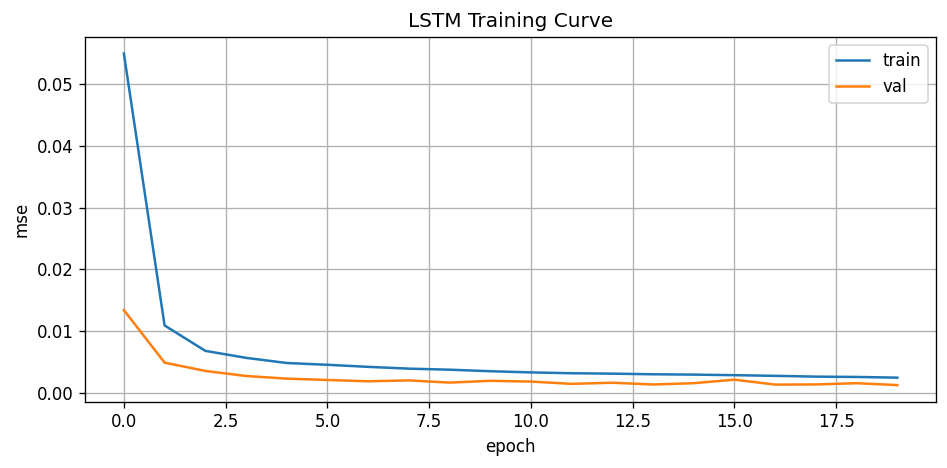

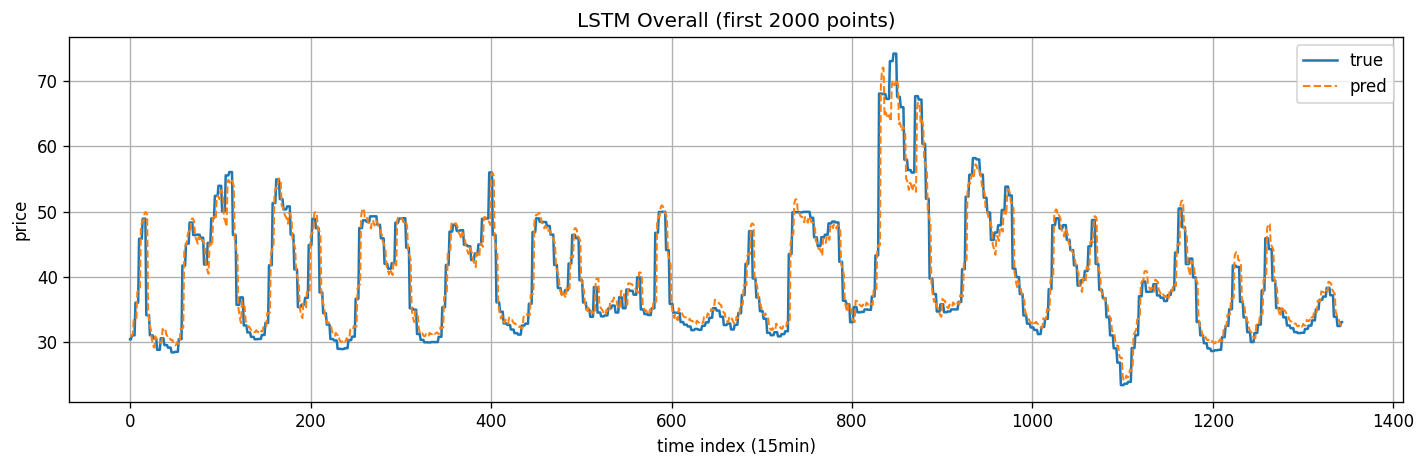

已保存: outputs\lstm_predictions_test.npz
npz keys: ['true', 'pred', 'err', 'abs_err', 'points_per_day', 'seq_len', 'pred_len', 'test_start_day', 'test_end_day', 'model']
true/pred shape: (1344,) (1344,)


In [8]:
from pathlib import Path
from typing import List
import numpy as np
import matplotlib.pyplot as plt

def plot_loss(train_losses: List[float], val_losses: List[float], title: str, save_path: Path):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="train")
    if len(val_losses) > 0:
        plt.plot(val_losses, label="val")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("mse")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

def plot_overall(true: np.ndarray, pred: np.ndarray, title: str, save_path: Path, max_points: int = 2000):
    n = min(len(true), max_points)
    plt.figure(figsize=(12, 4))
    plt.plot(true[:n], label="true", linewidth=1.5)
    plt.plot(pred[:n], label="pred", linestyle="--", linewidth=1.2)
    plt.title(title)
    plt.xlabel("time index (15min)")
    plt.ylabel("price")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

def save_predictions_npz(
    save_path: Path,
    true: np.ndarray,
    pred: np.ndarray,
    cfg,
    model_name: str = "lstm",
):
    """
    保存为 npz（MADRL 训练友好）：
    - true/pred: float32
    - 一些关键元信息，方便下游复现与对齐
    """
    save_path.parent.mkdir(parents=True, exist_ok=True)

    true = np.asarray(true, dtype=np.float32)
    pred = np.asarray(pred, dtype=np.float32)

    # 额外存一些常用信息（下游不需要可以不读）
    np.savez_compressed(
        save_path,
        true=true,
        pred=pred,
        err=(pred - true).astype(np.float32),
        abs_err=np.abs(pred - true).astype(np.float32),
        points_per_day=np.int32(cfg.POINTS_PER_DAY),
        seq_len=np.int32(cfg.SEQ_LEN),
        pred_len=np.int32(cfg.PRED_LEN),
        test_start_day=np.int32(cfg.TEST_START_DAY),
        test_end_day=np.int32(cfg.TEST_END_DAY),
        model=np.array(model_name),
    )

out_dir = Path(cfg.OUT_DIR)
plot_loss(lstm_train_losses, lstm_val_losses, "LSTM Training Curve", out_dir / "lstm_loss.png")
plot_overall(lstm_true, lstm_pred, "LSTM Overall (first 2000 points)", out_dir / "lstm_overall.png")

# 保存预测结果（npz）
npz_path = out_dir / "lstm_predictions_test.npz"
save_predictions_npz(npz_path, lstm_true, lstm_pred, cfg, model_name="lstm")
print("已保存:", npz_path)

# （可选）快速校验读取
tmp = np.load(npz_path, allow_pickle=True)
print("npz keys:", tmp.files)
print("true/pred shape:", tmp["true"].shape, tmp["pred"].shape)